<a href="https://colab.research.google.com/github/Ymin-2/ESAA/blob/main/ESAA_OB_WEEK13_2_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **13.3 적대적 생성 신경망(GAN)이란**

생성 모델은 최대한 진짜와 비슷한 데이터를 생성하려는 생성자와 진짜와 가짜를 구별하는 판별자가 각각 존재하여 서로 적대적으로 학습함

적대적 학습에서는 판별자를 먼저 학습시킨 후 생성자를 학습시키는 과정을 반복함

판별자 학습 단계
1. 실제 이미지를 입력해서 네트워크(신경망)가 해당 이미지를 진짜로 분류하도록 학습시킴
2. 생성자가 생성한 모조 이미지를 입력해서 해당 이미지를 가짜로 분류하도록 학습시킴

이 과정을 거쳐 판별자는 실제 이미지를 진짜로 분류하고, 모조 이미지를 가짜로 분류

### 13.3.1 GAN 동작 원리

생성자와 판별자 네트워크는 서로 적대적으로 경쟁하여 학습을 진행함

판별자 D의 역할: 주어진 입력 이미지가 진짜 이미지인지 가짜 이미지인지 구별  
-> 이미지가 입력으로 주어졌을 때 판별자의 출력이 진짜 이미지일 확률을 반환

생성자 G의 역할: 판별자가 진짜인지 가짜인지 구별할 수 없을 만큼 진짜와 같은 모조 이미지를 노이즈 데이터를 사용하여 만들어 내는 것

생성자는 임의의 노이즈 데이터를 사용해 모조 이미지를 생성

실제 데이터를 판단하려고 판별자를 학습시킬 때는 생성자를 고정시킨 채 실제 이미지는 높은 확률을 반환하는 방향으로, 모조 이미지는 낮은 확률을 반환하는 방향으로 가중치를 업데이트

### 13.3.2 GAN 구현

In [ ]:
# 13-22 라이브러리 호출
import imageio
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib
import matplotlib.pylab as plt

from torchvision.utils import make_grid, save_image
import torchvision.datasets as datasets
import torchvision.transforms as transforms
matplotlib.style.use('ggplot')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# 13-23 변수 값 설정
batch_size = 512
epochs = 200
sample_size = 64
nz = 128
k = 1

In [ ]:
# 13-24 MNIST를 내려받은 후 정규화
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,)),
])

train_dataset = datasets.MNIST(root = 'data', train = True, download = True, transform = transform)
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 501kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# 13-25 생성자 네트워크 생성
class Generator(nn.Module):
  def __init__(self, nz):
    super(Generator, self).__init__()
    self.nz = nz
    self.main = nn.Sequential(
        nn.Linear(self.nz, 256), nn.LeakyReLU(0.2),
        nn.Linear(256, 512), nn.LeakyReLU(0.2),
        nn.Linear(512, 1024), nn.LeakyReLU(0.2),
        nn.Linear(1024, 784), nn.Tanh(),
    )

  def forward(self, x):
    return self.main(x).view(-1, 1, 28, 28)

In [ ]:
# 13-26 판별자 네트워크 생성
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.n_input = 784 # 판별자의 입력 크기
    self.main = nn.Sequential(
        nn.Linear(self.n_input, 1024), nn.LeakyReLU(0.2),
        nn.Dropout(0.3), nn.Linear(1024, 512),
        nn.LeakyReLU(0.2), nn.Dropout(0.3),
        nn.Linear(512, 256), nn.LeakyReLU(0.2),
        nn.Dropout(0.3), nn.Linear(256, 1), nn.Sigmoid(),
    )

  def forward(self, x):
    x = x.view(-1, 784)
    return self.main(x)

In [ ]:
# 13-27 생성자와 판별자 네트워크 초기화
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [ ]:
# 13-28 옵티마이저와 손실 함수 정의
optim_g = optim.Adam(generator.parameters(), lr = 0.0002)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)

criterion = nn.BCELoss()

losses_g = []
losses_d = []
images = []

In [ ]:
# 13-29 생성된 이미지 저장 함수 정의
def save_generator_image(image, path):
  save_image(image, path)

In [ ]:
# 13-30 판별자 학습을 위한 함수
def train_discriminator(optimizer, data_real, data_fake):
  b_size = data_real.size(0)
  real_label = torch.ones(b_size, 1).to(device)
  fake_label = torch.zeros(b_size, 1).to(device)
  optimizer.zero_grad()
  output_real = discriminator(data_real)
  loss_real = criterion(output_real, real_label)
  output_fake = discriminator(data_fake)
  loss_fake = criterion(output_fake, fake_label)
  loss_real.backward()
  loss_fake.backward()
  optimizer.step()
  return loss_real + loss_fake

In [ ]:
# 13-31 생성자 학습을 위한 함수
def train_generator(optimizer, data_fake):
  b_size = data_fake.size(0)
  real_label = torch.ones(b_size, 1).to(device)
  optimizer.zero_grad()
  output = discriminator(data_fake)
  loss = criterion(output, real_label)
  loss.backward()
  optimizer.step()
  return loss

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 13-32 모델 학습
batch_size = 64
epochs = 20

generator.train()
discriminator.train()

for epoch in range(epochs):
  loss_g = 0.0
  loss_d = 0.0
  for idx, data in tqdm(enumerate(train_loader), total=int(len(train_dataset)/train_loader.batch_size)):
    image, _ = data
    image = image.to(device)
    b_size = len(image)
    for step in range(k):
      data_fake = generator(torch.randn(b_size, nz).to(device)).detach()
      data_real = image
      loss_d += train_discriminator(optim_d, data_real, data_fake)
    data_fake = generator(torch.randn(b_size, nz).to(device))
    loss_g += train_generator(optim_g, data_fake)
  generated_img = generator(torch.randn(b_size, nz).to(device)).cpu().detach()
  generated_img = make_grid(generated_img)
  save_generator_image(generated_img, f"/content/drive/MyDrive/ESAA/gen_img{epoch}.png")
  epoch_loss_g = loss_g / idx
  epoch_loss_d = loss_d / len(train_loader)
  losses_g.append(epoch_loss_g)
  losses_d.append(epoch_loss_d)

  print(f"Epoch {epoch} of {epochs}")
  print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
118it [00:12,  9.30it/s]                         


Epoch 0 of 20
Generator loss: 1.17244375, Discriminator loss: 0.97089690


118it [00:12,  9.24it/s]                         


Epoch 1 of 20
Generator loss: 1.40593958, Discriminator loss: 1.26522636


118it [00:13,  8.88it/s]                         


...

Epoch 17 of 20
Generator loss: 2.08763552, Discriminator loss: 0.80652255


118it [00:12,  9.41it/s]                         


Epoch 18 of 20
Generator loss: 2.10139751, Discriminator loss: 0.66802460


118it [00:13,  8.86it/s]                         


Epoch 19 of 20
Generator loss: 2.55173421, Discriminator loss: 0.59150803


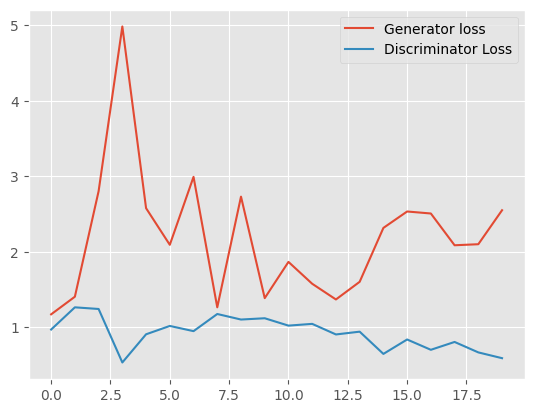

In [ ]:
# 13-33 생성자와 판별자의 오차 확인
plt.figure()
losses_g = [fl.item() for fl in losses_g]
plt.plot(losses_g, label='Generator loss')
losses_d = [f2.item() for f2 in losses_d]
plt.plot(losses_d, label='Discriminator Loss')
plt.legend()

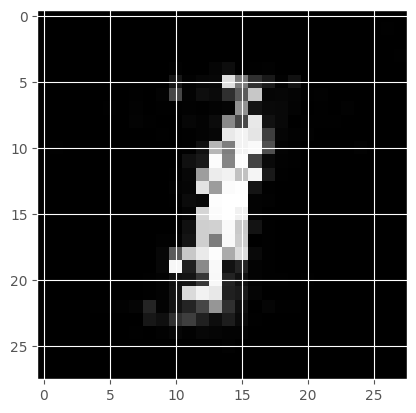

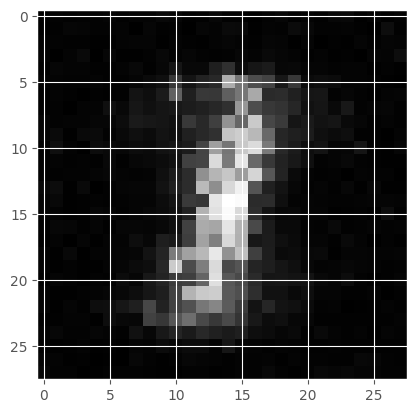

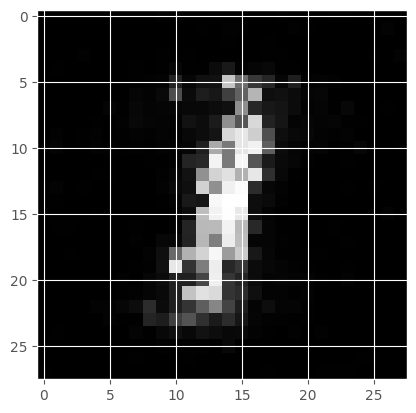

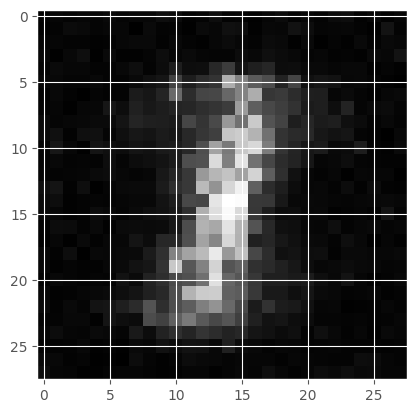

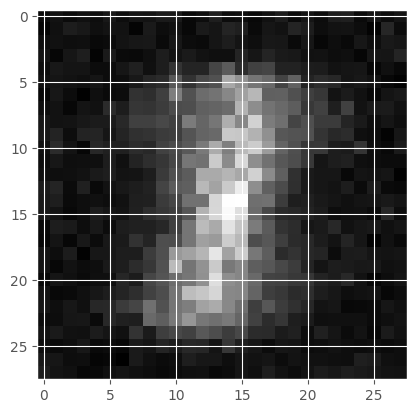

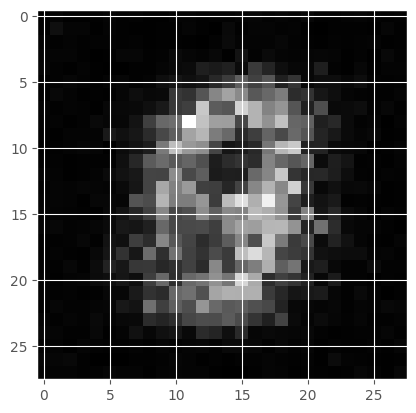

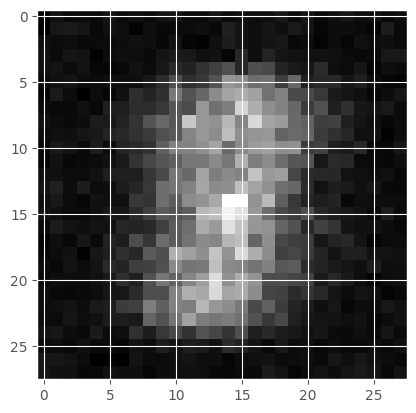

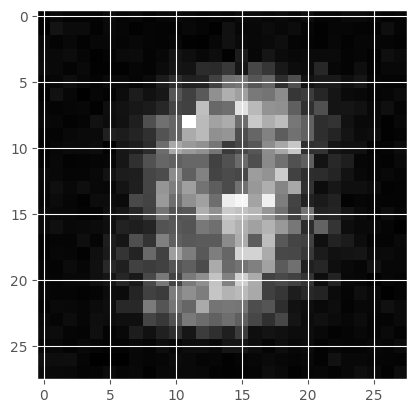

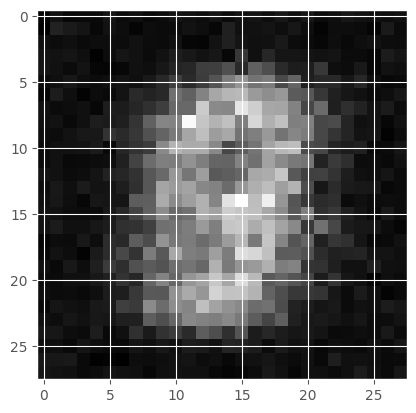

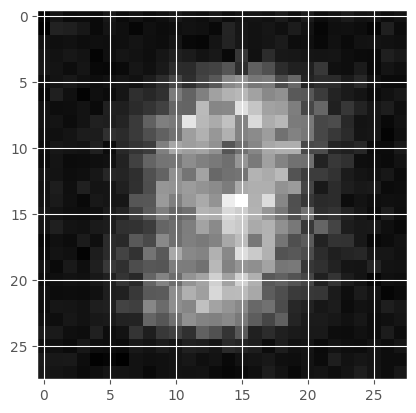

In [ ]:
# 13-34 생성된 이미지 출력
import numpy as np

fake_images = generator(torch.randn(b_size, nz).to(device))
for i in range(10):
  fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))
  plt.imshow(fake_images_img, cmap='gray')
  plt.savefig('/content/drive/MyDrive/ESAA/fake_images_img' + str(i) + '.png')
  plt.show()

## **13.4 GAN 파생 기술**

GAN은 생성자와 판별자가 서로 대결하면서 학습하는 구조이기 때문에 학습이 매우 불안정함

생성자와 판별자 중 한쪽으로 치우친 훈련이 발생하면 성능에 문제가 생겨 정상적인 분류가 불가능

이러한 제약을 해결한 모델: DCGAN: GAN 학습에 CNN을 사용하는 것

GAN, DCGAN: 가짜 이미지 생성을 위해 임의의 노이즈 값 사용  
cGAN: 출력에 어떤 조건을 주어 변형하는 모델.

즉, GAN이 임의의 노이즈로 무작위 이미지를 출력한다면, cGAN은 시드 역할을 하는 임의의 노이즈와 함께 어떤 조건이 추가됨

CycleGAN: 사진이 주어졌을 때 다른 사진으로 변형시키는 모델

### 13.4.1 DCGAN

: GAN과 동일하게 입력된 이미지를 바탕으로 그것과 매우 유사한 가짜 이미지를 만들고, 이를 평가하는 과정을 반복하여 실제와 매우 유사한 이미지를 생산하는 학습법

**생성자 네트워크**

생성자는 임의의 입력을 받아들여 판별자에서 사용할 수 있는 이미지 데이터를 생성, 출력은 64X64

임의의 입력으로 주어지는 노이즈 데이터는 '가로x세로' 형태가 아니기 때문에 입력 형태를 '가로x세로'로 변경

형태가 변경된 입력은 합성곱층으로 넘겨진 후 이미지 형태의 출력을 위해 분수-스트라이드 합성곱 사용해 출력 값을 키움

특징
- 풀링층을 모두 없애고, 분수-스트라이드 합성곱 사용
- 배치 정규화를 이용해 네트워크의 층이 많아도 안정적으로 기울기를 계산할 수 있도록 함. 단 배치 정규화를 모든 계층마다 추가할 경우 안정성이 떨어지는 문제가 있으므로 최종 출력층에서는 사용하지 않음
- 활성화 함수는 렐루 사용, 최종 출력층에서는 하이퍼볼릭 탄젠트 사용

**판별자 네트워크**

: 64x64 크기의 이미지를 입력받아 진짜 혹은 가짜의 1차원 결과 출력

활성화 함수로 리키렐루 사용, 최종 출력층에서는 시그모이드 함수 사용

### 13.4.2 cGAN

: GAN의 출력에 조건을 주어 통제하려는 시도에서 만들어짐

### 13.4.3 CycleGAN

GAN, DCGAN은 랜덤 노이즈를 입력으로 하므로 무작위 데이터가 생성되기 때문에 원하는 결과를 얻기 어려운 문제가 있음. 이런한 문제를 해결하는 방법: PIX2PIX

**PIX2PIX**

: 임의의 노이즈 벡터가 아닌 이미지를 입력으로 받아 다른 스타일의 이미지를 출력하는 지도 학습 알고리즘

이를 학습하려면 입력을 위한 데이터셋과 PIX2PIX를 거쳐서 나올 정답 이미지가 필요

**생성자 네트워크**

입력과 출력이 모두 이미지이기 때문에 전체적으로 크기가 줄어들었다가 다시 커지는 인코더-디코더 구조

크기가 줄어드는 인코더에서는 입력 데이터의 특징을 찾아내고, 크기가 다시 커지는 디코더에서는 이미지를 생성하는 역할을 함

**판별자 네트워크**

DCGAN과 마찬가지로 스트라이드가 2인 합성곱층으로 구성됨

뒤의 두 계층은 스트라이드가 1인 밸리드 합성곱을 이용해 최종적으로 30x30 형태의 데이터를 출력

<-- 판별자를 이미지의 각 부분별로 진행하기 위해서

판별자는 이미지를 통째로 진짜인지 아닌지 판별하는 것이 아니라 이미지의 각 부분이 진짜인지 아닌지 판별

**CycleGAN**

: 쌍을 이루지 않는 이미지로 학습할 때 사용하는 것

하나가 아닌 두 개의 생성자를 가짐